In [1]:
#Importe les bibliothèques :
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Pandas version :", pd.__version__)

Pandas version : 3.0.1


In [2]:
#La Series (colonne unique) :
# Une Series = une colonne de données avec un index
temperatures = pd.Series([28, 32, 30, 35, 29, 33, 31],
                         index=["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"])

print("Températures :\n", temperatures)
print("\nMoyenne :", temperatures.mean())
print("Max :", temperatures.max())
print("Jour le plus chaud :", temperatures.idxmax())

Températures :
 Lun    28
Mar    32
Mer    30
Jeu    35
Ven    29
Sam    33
Dim    31
dtype: int64

Moyenne : 31.142857142857142
Max : 35
Jour le plus chaud : Jeu


In [3]:
 ##Créer un DataFrame manuellement :
# Un DataFrame = plusieurs Series assemblées
employes = pd.DataFrame({
    "nom": ["Alice", "Bob", "Carol", "David", "Eve"],
    "age": [28, 35, 24, 42, 31],
    "departement": ["Tech", "Marketing", "Tech", "RH", "Marketing"],
    "salaire": [850000, 650000, 780000, 720000, 690000],
    "annees_exp": [3, 8, 1, 15, 6]
})

print(employes)
print("\nShape :", employes.shape)
print("\nTypes des colonnes :\n", employes.dtypes)
print("\nAperçu statistique :\n", employes.describe())

     nom  age departement  salaire  annees_exp
0  Alice   28        Tech   850000           3
1    Bob   35   Marketing   650000           8
2  Carol   24        Tech   780000           1
3  David   42          RH   720000          15
4    Eve   31   Marketing   690000           6

Shape : (5, 5)

Types des colonnes :
 nom              str
age            int64
departement      str
salaire        int64
annees_exp     int64
dtype: object

Aperçu statistique :
              age        salaire  annees_exp
count   5.000000       5.000000    5.000000
mean   32.000000  738000.000000    6.600000
std     6.892024   78549.347547    5.412947
min    24.000000  650000.000000    1.000000
25%    28.000000  690000.000000    3.000000
50%    31.000000  720000.000000    6.000000
75%    35.000000  780000.000000    8.000000
max    42.000000  850000.000000   15.000000


In [4]:
#Charger un vrai dataset :
# Charger le dataset Titanic (dataset classique en data science)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Les premières infos essentielles
print("Shape :", df.shape)
print("\n5 premières lignes :")
df.head()

Shape : (891, 12)

5 premières lignes :


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
#Explorer le dataset :
# Les infos générales du dataset
print("=== INFOS GÉNÉRALES ===")
df.info()

print("\n=== STATISTIQUES DESCRIPTIVES ===")
df.describe()

# Valeurs manquantes — très important en data science !
print("=== VALEURS MANQUANTES ===")
print(df.isnull().sum())

print("\n=== POURCENTAGE MANQUANT ===")
print((df.isnull().sum() / len(df) * 100).round(2))

=== INFOS GÉNÉRALES ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

=== STATISTIQUES DESCRIPTIVES ===
=== VALEURS MANQUANTES ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fa

In [12]:
# Nettoyage des valeurs manquantes :
# 1. Supprimer la colonne Cabin
df = df.drop(columns=["Cabin"])
print("Colonne Cabin supprimée ✅")

# 2. Imputer Age par la médiane
mediane_age = df["Age"].median()
df["Age"] = df["Age"].fillna(mediane_age)
print(f"Age imputé par la médiane : {mediane_age} ans ✅")

# 3. Imputer Embarked par le mode
mode_embarked = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(mode_embarked)
print(f"Embarked imputé par le mode : {mode_embarked} ✅")

# Vérification
print("\n=== VALEURS MANQUANTES APRÈS NETTOYAGE ===")
print(df.isnull().sum())

KeyError: "['Cabin'] not found in axis"

In [7]:
##Sélection de colonnes :
# Sélectionner une colonne
ages = df["Age"]
print("Type :", type(ages))
print(ages.head())

# Sélectionner plusieurs colonnes
essentiels = df[["Name", "Age", "Sex", "Survived"]]
print("\n", essentiels.head())

# Sélectionner avec loc (par étiquette)
print("\nLigne 0 à 4, colonnes Name et Age :")
print(df.loc[0:4, ["Name", "Age"]])

# Sélectionner avec iloc (par position)
print("\n3 premières lignes, 3 premières colonnes :")
print(df.iloc[0:3, 0:3])

Type : <class 'pandas.Series'>
0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64

                                                 Name   Age     Sex  Survived
0                            Braund, Mr. Owen Harris  22.0    male         0
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0  female         1
2                             Heikkinen, Miss. Laina  26.0  female         1
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0  female         1
4                           Allen, Mr. William Henry  35.0    male         0

Ligne 0 à 4, colonnes Name et Age :
                                                Name   Age
0                            Braund, Mr. Owen Harris  22.0
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0
2                             Heikkinen, Miss. Laina  26.0
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0
4                           Allen, Mr. William Henry  35.0

3 premières lignes, 3 premières colon

In [8]:
##Filtrage des données :
# Filtrer les survivants
survivants = df[df["Survived"] == 1]
print("Nombre de survivants :", len(survivants))

# Filtrer les femmes
femmes = df[df["Sex"] == "female"]
print("Nombre de femmes :", len(femmes))

# Filtrer les femmes survivantes
femmes_survivantes = df[(df["Sex"] == "female") & (df["Survived"] == 1)]
print("Femmes survivantes :", len(femmes_survivantes))

# Filtrer les passagers de plus de 50 ans
seniors = df[df["Age"] > 50]
print("Passagers > 50 ans :", len(seniors))

# Filtrer par classe
premiere_classe = df[df["Pclass"] == 1]
print("Passagers 1ère classe :", len(premiere_classe))

# Taux de survie par sexe
print("\n=== TAUX DE SURVIE PAR SEXE ===")
print(df.groupby("Sex")["Survived"].mean() * 100)

Nombre de survivants : 342
Nombre de femmes : 314
Femmes survivantes : 233
Passagers > 50 ans : 64
Passagers 1ère classe : 216

=== TAUX DE SURVIE PAR SEXE ===
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [9]:
##Tri des données :
# Trier par age croissant
df_age_croissant = df.sort_values("Age")
print("=== 5 passagers les plus jeunes ===")
print(df_age_croissant[["Name", "Age", "Sex", "Survived"]].head())

# Trier par age décroissant
df_age_decroissant = df.sort_values("Age", ascending=False)
print("\n=== 5 passagers les plus âgés ===")
print(df_age_decroissant[["Name", "Age", "Sex", "Survived"]].head())

# Trier par plusieurs colonnes
df_multi = df.sort_values(["Pclass", "Fare"], ascending=[True, False])
print("\n=== Tri par classe puis tarif décroissant ===")
print(df_multi[["Name", "Pclass", "Fare"]].head(8))

=== 5 passagers les plus jeunes ===
                                Name   Age     Sex  Survived
803  Thomas, Master. Assad Alexander  0.42    male         1
755        Hamalainen, Master. Viljo  0.67    male         1
644           Baclini, Miss. Eugenie  0.75  female         1
469    Baclini, Miss. Helene Barbara  0.75  female         1
831  Richards, Master. George Sibley  0.83    male         1

=== 5 passagers les plus âgés ===
                                     Name   Age   Sex  Survived
630  Barkworth, Mr. Algernon Henry Wilson  80.0  male         1
851                   Svensson, Mr. Johan  74.0  male         0
96              Goldschmidt, Mr. George B  71.0  male         0
493               Artagaveytia, Mr. Ramon  71.0  male         0
116                  Connors, Mr. Patrick  70.5  male         0

=== Tri par classe puis tarif décroissant ===
                                   Name  Pclass      Fare
258                    Ward, Miss. Anna       1  512.3292
679  Cardeza, Mr

In [13]:

##Groupby (l'outil le plus puissant de Pandas) :
# Taux de survie par classe
print("=== TAUX DE SURVIE PAR CLASSE ===")
print(df.groupby("Pclass")["Survived"].mean() * 100)

# Age moyen par classe
print("\n=== AGE MOYEN PAR CLASSE ===")
print(df.groupby("Pclass")["Age"].mean().round(1))

# Tarif moyen par classe
print("\n=== TARIF MOYEN PAR CLASSE ===")
print(df.groupby("Pclass")["Fare"].mean().round(2))

# Plusieurs agrégations en même temps
print("\n=== STATISTIQUES PAR CLASSE ===")
print(df.groupby("Pclass").agg({
    "Survived": "mean",
    "Age": "mean",
    "Fare": "mean",
    "PassengerId": "count"
}).round(2))

=== TAUX DE SURVIE PAR CLASSE ===
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

=== AGE MOYEN PAR CLASSE ===
Pclass
1    36.8
2    29.8
3    25.9
Name: Age, dtype: float64

=== TARIF MOYEN PAR CLASSE ===
Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64

=== STATISTIQUES PAR CLASSE ===
        Survived    Age   Fare  PassengerId
Pclass                                     
1           0.63  36.81  84.15          216
2           0.47  29.77  20.66          184
3           0.24  25.93  13.68          491


**Ce que les données racontent : les passagers de 1ère classe étaient plus riches (tarif 84 vs 13), plus âgés, et ont eu plus accès aux canots de sauvetage. La classe sociale a donc joué un rôle majeur dans la survie — la data confirme une inégalité sociale tragique !**

In [14]:
# Transformation et création de nouvelles colonnes :
# Créer une colonne catégorielle d'âge
def categoriser_age(age):
    if age < 18:
        return "Enfant"
    elif age < 35:
        return "Jeune adulte"
    elif age < 60:
        return "Adulte"
    else:
        return "Senior"

df["categorie_age"] = df["Age"].apply(categoriser_age)
print("=== RÉPARTITION PAR CATÉGORIE D'ÂGE ===")
print(df["categorie_age"].value_counts())

# Taux de survie par catégorie d'âge
print("\n=== TAUX DE SURVIE PAR CATÉGORIE D'ÂGE ===")
print(df.groupby("categorie_age")["Survived"].mean() * 100)

# Créer une colonne famille
df["taille_famille"] = df["SibSp"] + df["Parch"] + 1
df["seul"] = df["taille_famille"] == 1

# Taux de survie seul vs en famille
print("\n=== SURVIE SEUL VS EN FAMILLE ===")
print(df.groupby("seul")["Survived"].mean() * 100)

=== RÉPARTITION PAR CATÉGORIE D'ÂGE ===
categorie_age
Jeune adulte    543
Adulte          209
Enfant          113
Senior           26
Name: count, dtype: int64

=== TAUX DE SURVIE PAR CATÉGORIE D'ÂGE ===
categorie_age
Adulte          41.626794
Enfant          53.982301
Jeune adulte    34.438306
Senior          26.923077
Name: Survived, dtype: float64

=== SURVIE SEUL VS EN FAMILLE ===
seul
False    50.564972
True     30.353818
Name: Survived, dtype: float64


**apply() applique une fonction sur chaque ligne — c'est l'équivalent vectorisé d'une boucle for en Pandas. Tu peux lui passer n'importe quelle fonction Python !**

**Ce que les données racontent :
Les enfants ont été prioritaires dans les canots → 53% de survie
Les passagers en famille ont mieux survécu que les solitaires → probablement parce qu'ils s'entraidaient pour trouver les canots de sauvetage !**

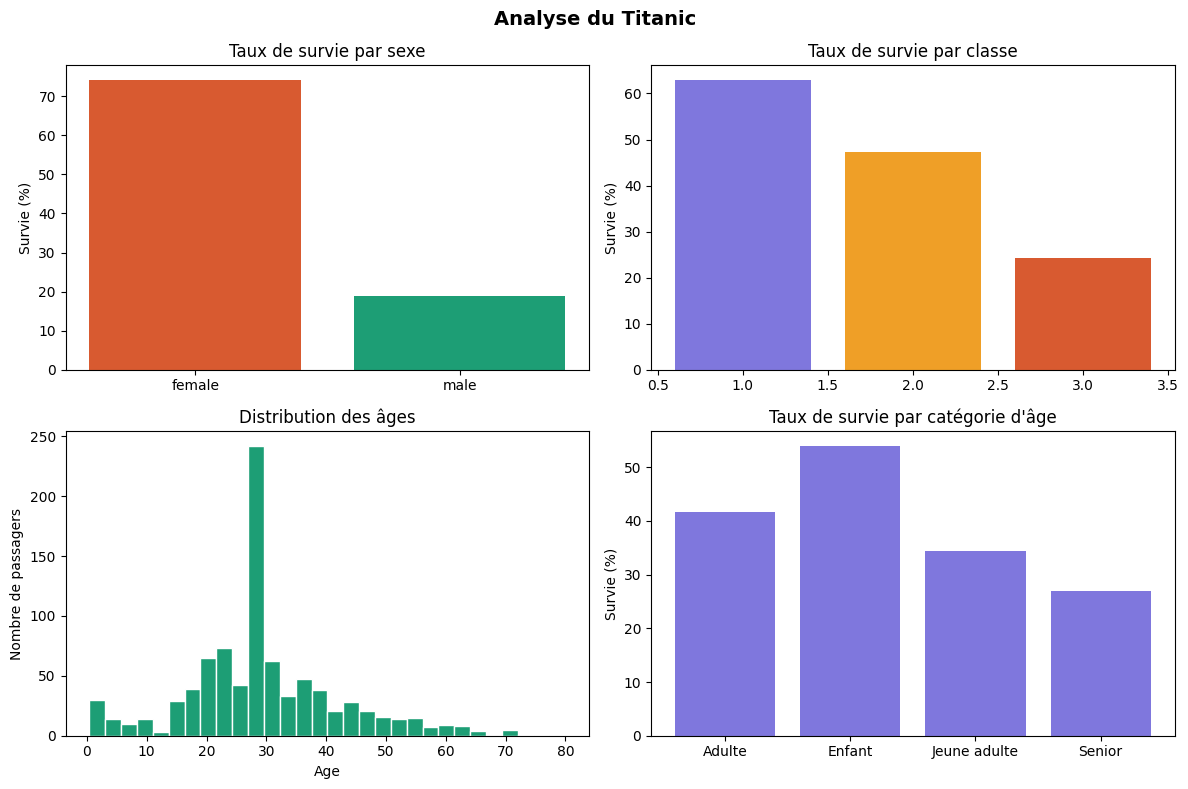

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Taux de survie par sexe
survie_sexe = df.groupby("Sex")["Survived"].mean() * 100
axes[0,0].bar(survie_sexe.index, survie_sexe.values, 
              color=["#D85A30", "#1D9E75"])
axes[0,0].set_title("Taux de survie par sexe")
axes[0,0].set_ylabel("Survie (%)")

# 2. Taux de survie par classe
survie_classe = df.groupby("Pclass")["Survived"].mean() * 100
axes[0,1].bar(survie_classe.index, survie_classe.values,
              color=["#7F77DD", "#EF9F27", "#D85A30"])
axes[0,1].set_title("Taux de survie par classe")
axes[0,1].set_ylabel("Survie (%)")

# 3. Distribution des âges
axes[1,0].hist(df["Age"], bins=30, color="#1D9E75", edgecolor="white")
axes[1,0].set_title("Distribution des âges")
axes[1,0].set_xlabel("Age")
axes[1,0].set_ylabel("Nombre de passagers")

# 4. Taux de survie par catégorie d'âge
survie_age = df.groupby("categorie_age")["Survived"].mean() * 100
axes[1,1].bar(survie_age.index, survie_age.values, color="#7F77DD")
axes[1,1].set_title("Taux de survie par catégorie d'âge")
axes[1,1].set_ylabel("Survie (%)")

plt.suptitle("Analyse du Titanic", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**💡 subplots(2, 2) crée une grille de 4 graphiques — très utilisé en data science pour avoir une vue d'ensemble des données en un seul coup d'œil !**

Information generale du data set:
 dimension :
 (100, 9) 
 types de colonnes:
 commande_id     int64
client            str
produit           str
categorie         str
montant         int32
quantite        int32
ville             str
mois              str
satisfaction    int64
dtype: object 
 statistiques descriptive:
        commande_id        montant    quantite  satisfaction
count   100.000000     100.000000  100.000000    100.000000
mean     50.500000  252001.810000    4.750000      3.200000
std      29.011492  145631.925857    2.591263      1.477098
min       1.000000    7869.000000    1.000000      1.000000
25%      25.750000  131537.000000    2.750000      2.000000
50%      50.500000  267434.500000    5.000000      3.500000
75%      75.250000  380897.750000    7.000000      4.250000
max     100.000000  497738.000000    9.000000      5.000000
Meilleur client : Alice avec 6,404,462 FCFA


'Le montant moyen par ville:'

ville
Bafoussam    289367.684211
Douala       246795.615385
Garoua       222680.678571
Yaoundé      261127.777778
Name: montant, dtype: float64

'***'

,client,ville
0,David,Douala
1,Eve,Bafoussam
2,Carol,Bafoussam
3,Eve,Garoua
4,Eve,Yaoundé
...,...,...
95,Carol,Garoua
96,Eve,Douala
97,Bob,Yaoundé
98,Bob,Yaoundé


produit
Tablette      141
Téléphone     136
Accessoire    113
Laptop         85
Name: quantite, dtype: int32

'Le produit le plus vendu en quantité est:'

'Tablette'

Satisfaction moyenne par produit :
 produit
Accessoire    3.29
Laptop        3.20
Tablette      3.16
Téléphone     3.16
Name: satisfaction, dtype: float64
voici le chiffre d'affaire par ville ville
Bafoussam    5497986
Douala       6416686
Garoua       6235059
Yaoundé      7050450
Name: montant, dtype: int32


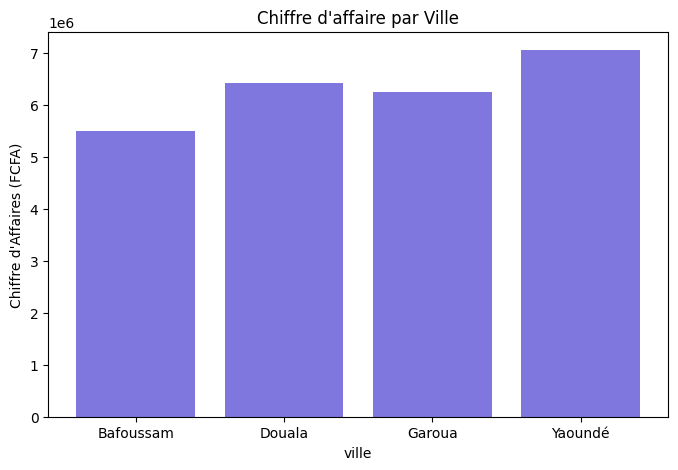

=== MOYENNE vs MÉDIANE PAR VILLE ===
               mean    median     max
ville                                
Bafoussam  289368.0  286974.0  488951
Douala     246796.0  236025.0  497738
Garoua     222681.0  197793.0  459351
Yaoundé    261128.0  311208.0  475587


C:\Users\BARTHOLOMEW\AppData\Local\Temp\ipykernel_8600\340822643.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ville", y="montant", data=df_ventes, palette="Set3")


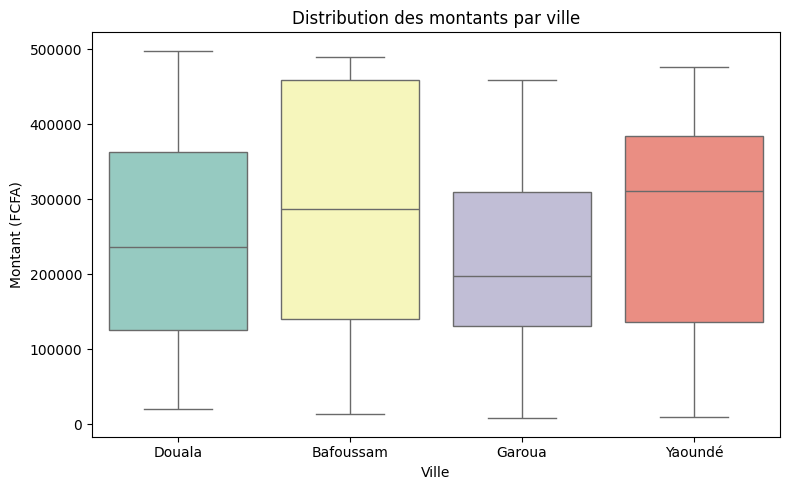

Q1 : 131,537 FCFA
Q3 : 380,898 FCFA
IQR : 249,361 FCFA
Borne inférieure : -242,504 FCFA
Borne supérieure : 754,939 FCFA
Nombre d'outliers : 0


In [80]:
##### Exercice pratique !
#Contexte : Tu es data scientist dans une startup de e-commerce camerounaise. Voici les données de ventes :

import pandas as pd
import numpy as np

np.random.seed(42)

data = {
    "commande_id": range(1, 101),
    "client": np.random.choice(["Alice", "Bob", "Carol", "David", "Eve"], 100),
    "produit": np.random.choice(["Téléphone", "Laptop", "Tablette", "Accessoire"], 100),
    "categorie": np.random.choice(["Electronique", "Accessoire"], 100),
    "montant": np.random.randint(5000, 500000, 100),
    "quantite": np.random.randint(1, 10, 100),
    "ville": np.random.choice(["Douala", "Yaoundé", "Bafoussam", "Garoua"], 100),
    "mois": np.random.choice(["Jan", "Fév", "Mar", "Avr", "Mai", "Juin"], 100),
    "satisfaction": np.random.choice([1, 2, 3, 4, 5], 100)
}

df_ventes = pd.DataFrame(data)
#1-Affiche les infos générales du dataset (shape, dtypes, describe)
print("Information generale du data set:\n dimension :\n",df_ventes.shape,"\n types de colonnes:\n",df_ventes.dtypes,"\n statistiques descriptive:\n",df_ventes.describe())

#2-Trouve le client qui a généré le plus de chiffre d'affaires

# La bonne approche : sommer TOUTES les commandes par client
ca_par_client = df_ventes.groupby("client")["montant"].sum()
meilleur_client = ca_par_client.idxmax()
print(f"Meilleur client : {meilleur_client} avec {ca_par_client.max():,} FCFA")

#3-Calcule le montant moyen par ville
montant_moyen_par_ville=df_ventes.groupby('ville')['montant'].mean()
display("Le montant moyen par ville:",montant_moyen_par_ville)
display("***",df_ventes[["client","ville" ]])
#4-Trouve le produit le plus vendu en quantité
df_decroissant1=df_ventes.groupby('produit')['quantite'].sum().sort_values( ascending=False)
display(df_decroissant1.head(5))
produit_le_plus_vendu_qte=df_decroissant1.idxmax()
display("Le produit le plus vendu en quantité est:",produit_le_plus_vendu_qte)
# 5-Calcule le taux de satisfaction moyen par produit
# La satisfaction est notée de 1 à 5
taux = df_ventes.groupby("produit")["satisfaction"].mean().round(2)
print("Satisfaction moyenne par produit :\n", taux)
#6-Trace un graphique montrant le chiffre d'affaires par ville
ca_ville = df_ventes.groupby("ville")["montant"].sum() 
print("voici le chiffre d'affaire par ville",ca_ville)
# Création du graphique
plt.figure(figsize=(8, 5)) # Définit la taille de l'image
plt.bar(ca_ville.index, ca_ville.values, color='#7F77DD')
#sns.boxplot(x="ville", y="montant", data=df_ventes, palette="Set3")
"""Le boxplot montre la distribution des valeurs — il est adapté quand tu veux voir 
la dispersion des montants par ville. Mais ici tu veux comparer le total par ville → bar plot est le bon choix ! """

# Personnalisation
plt.title("Chiffre d'affaire par Ville")
plt.xlabel('ville')
plt.ylabel('Chiffre d\'Affaires (FCFA)')
plt.show()

# Comparons moyenne vs médiane par ville
print("=== MOYENNE vs MÉDIANE PAR VILLE ===")
print(df_ventes.groupby("ville")["montant"].agg(["mean", "median", "max"]).round(0))

plt.figure(figsize=(8, 5))
sns.boxplot(x="ville", y="montant", data=df_ventes, palette="Set3")
plt.title("Distribution des montants par ville")
plt.xlabel("Ville")
plt.ylabel("Montant (FCFA)")
plt.tight_layout()
plt.show()
# Calculer les outliers manuellement avec la méthode IQR
Q1 = df_ventes["montant"].quantile(0.25)
Q3 = df_ventes["montant"].quantile(0.75)
IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

outliers = df_ventes[(df_ventes["montant"] < borne_inf) | 
                     (df_ventes["montant"] > borne_sup)]

print(f"Q1 : {Q1:,.0f} FCFA")
print(f"Q3 : {Q3:,.0f} FCFA")
print(f"IQR : {IQR:,.0f} FCFA")
print(f"Borne inférieure : {borne_inf:,.0f} FCFA")
print(f"Borne supérieure : {borne_sup:,.0f} FCFA")
print(f"Nombre d'outliers : {len(outliers)}")

**Ton travail :**

1-Affiche les infos générales du dataset (shape, dtypes, describe)
2-Trouve le client qui a généré le plus de chiffre d'affaires
3-Calcule le montant moyen par ville
4-Trouve le produit le plus vendu en quantité
5-Calcule le taux de satisfaction moyen par produit
6-Trace un graphique montrant le chiffre d'affaires par ville